In [19]:
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error
from utils import meanMAE
import simtk.openmm as mm
import simtk.openmm.app as app
from simtk import unit
import numpy as np
import pandas as pd
import torch

In [ ]:
pdb = app.PDBFile('./aaa.pdb')  
forcefield = app.ForceField('amber99sb.xml', 'tip3p.xml')
system = forcefield.createSystem(pdb.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
integrator = mm.LangevinIntegrator(300*unit.kelvin, 1/unit.picosecond, 0.002*unit.picoseconds)

simulation = app.Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

In [21]:
n_steps = 1000
positions = []

for step in range(n_steps):
    simulation.step(1)
    state = simulation.context.getState(getPositions=True)
    positions.append(state.getPositions()[0][0]._value) 

time = np.arange(n_steps) * 0.002  
data = pd.Series(positions, index=time)

/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


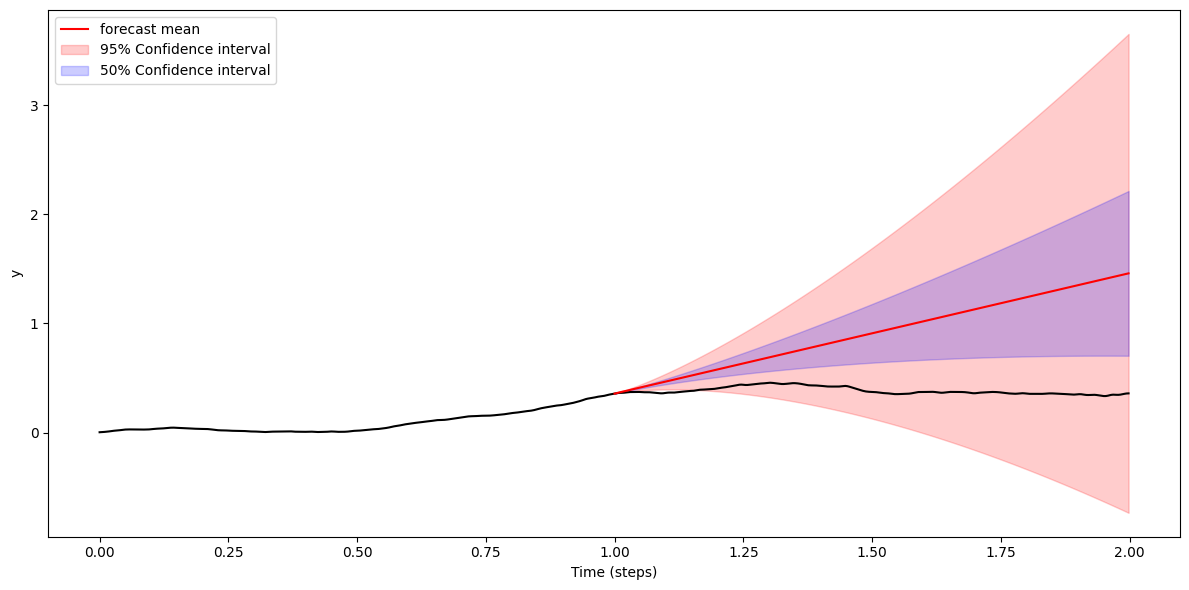

In [27]:
split = 500
model = pm.auto_arima(data.iloc[:split], seasonal=False, suppress_warnings=True)
result = model.arima_res_

steps = len(data) - split
forecast_res = result.get_forecast(steps=steps)
ci95 = forecast_res.conf_int(alpha=0.05)
ci95.index = data.index[split:]
test =data.iloc[split:]

plt.figure(figsize=(12, 6))
plt.plot(data.index, data, color="black")
plt.plot(test.index,forecast_res.predicted_mean,color="red",label="forecast mean")

n_sim = 0
sim_preds = []
for _ in range(n_sim):
    sim = result.simulate(nsimulations=steps)
    sim_preds.append(torch.tensor(sim.values))
    
plt.fill_between(ci95.index, ci95.iloc[:, 0], ci95.iloc[:, 1],color="red",alpha=0.2,label="95% Confidence interval")

for sim in sim_preds:
    plt.plot(test.index,sim,color="pink")

ci50 = forecast_res.conf_int(alpha=0.5)
ci50.index = test.index

plt.fill_between(ci50.index, ci50.iloc[:, 0], ci50.iloc[:, 1],color="blue",alpha=0.2,label="50% Confidence interval")
plt.xlabel("Time (steps)")
plt.ylabel("y")

plt.legend()
plt.tight_layout()
plt.show()
